# L3 —— 髓系细胞的亚群识别

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/immune"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(ANNO_DIR, "L3_immune_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_Myeloid_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_Myeloid_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取


In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 187365 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

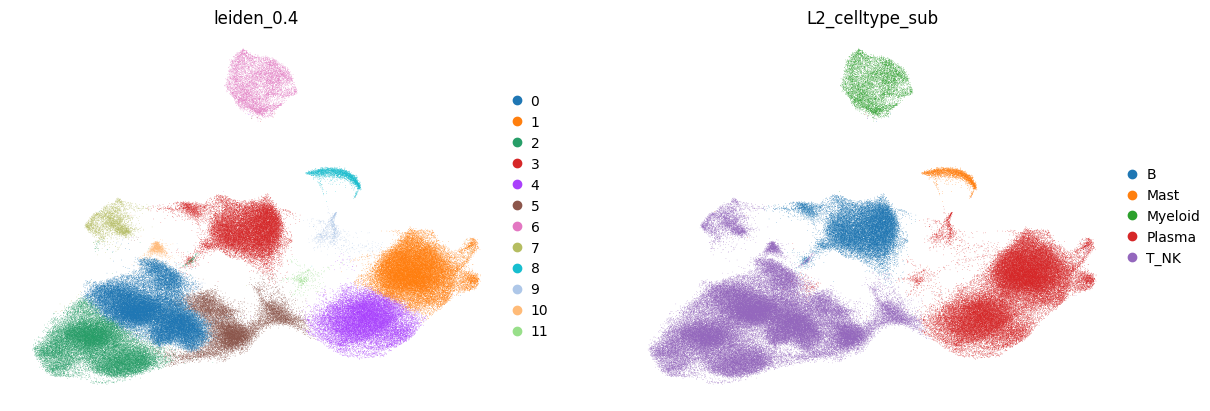

In [3]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,
)

In [4]:
adata.obs["L2_celltype_sub"].value_counts()

L2_celltype_sub
T_NK       95433
Plasma     58095
B          23996
Myeloid     7272
Mast        2569
Name: count, dtype: int64

## 对髓系细胞进行细分

In [5]:
sub = adata[adata.obs["L2_celltype_sub"]=="Myeloid"].copy()
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'L2_celltype_sub_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

简化一下亚群对象

In [6]:
# 1. 删除之前的降维
for key in ["X_pca", "X_pca_harmony", "X_scVI", "X_umap"]:
    if key in sub.obsm:
        del sub.obsm[key]
# 2. 删除之前的 graph（neighbors）
for key in ["neighbors"]:
    if key in sub.uns:
        del sub.uns[key]
for key in ["distances", "connectivities"]:
    if key in sub.obsp:
        del sub.obsp[key]
# 4. 删除 var 中不再需要的高变基因标记
for key in ["highly_variable", "highly_variable_rank",
            "means", "variances", "variances_norm"]:
    if key in sub.var:
        del sub.var[key]
# 5. 删除 uns 中各种配色、聚类结果、rank_genes_groups
keys_to_remove = [
    k for k in sub.uns.keys()
    if ("colors" in k) or ("leiden" in k) or ("rank_genes_groups" in k)
]
for k in keys_to_remove:
    del sub.uns[k]
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [7]:
# 若有原始计数，先切回 counts 再开始标准流程
if "counts" in sub.layers:
    sub.X = sub.layers["counts"]

## HVG → PCA → Harmony → neighbors → leiden

In [8]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    layers: 'counts'

In [10]:
# 标记 HVG，但不裁剪基因
sc.pp.highly_variable_genes(
    sub, n_top_genes=2000, flavor="seurat_v3",
    subset=False, span=0.5, check_values=False
)
hv_mask = sub.var["highly_variable"].values

In [11]:
# 仅在 HVG 上做 PCA（不丢非HVG；把结果写回到 sub）
sub_hv = sub[:, hv_mask].copy()
sc.pp.scale(sub_hv, max_value=10)
sc.tl.pca(sub_hv, n_comps=50, svd_solver="arpack")
sub.obsm["X_pca"] = sub_hv.obsm["X_pca"]
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca'
    layers: 'counts'

根据不同的数据集批次去除批次效应

In [12]:
# Harmony 去批次（基于 PCA）
sce.pp.harmony_integrate(sub, key="GSE", basis="X_pca")
sub

2025-12-01 13:23:39,132 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2025-12-01 13:23:40,440 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-01 13:23:40,463 - harmonypy - INFO - Iteration 1 of 10
2025-12-01 13:23:41,473 - harmonypy - INFO - Iteration 2 of 10
2025-12-01 13:23:42,468 - harmonypy - INFO - Iteration 3 of 10
2025-12-01 13:23:43,467 - harmonypy - INFO - Iteration 4 of 10
2025-12-01 13:23:44,457 - harmonypy - INFO - Iteration 5 of 10
2025-12-01 13:23:45,408 - harmonypy - INFO - Iteration 6 of 10
2025-12-01 13:23:46,449 - harmonypy - INFO - Iteration 7 of 10
2025-12-01 13:23:46,998 - harmonypy - INFO - Converged after 7 iterations


AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap'
    obsm: 'X_pca', 'X_pca_harmony'
    layers: 'counts'

In [13]:
# 邻域/聚类/UMAP
sc.pp.neighbors(sub, use_rep="X_pca_harmony", n_neighbors=20)
sc.tl.umap(sub)

In [14]:
sc.tl.leiden(sub, resolution=0.2, key_added=f"leiden_0.2_Myeloid")
sc.tl.leiden(sub, resolution=0.4, key_added=f"leiden_0.5_Myeloid")

查看批次效应

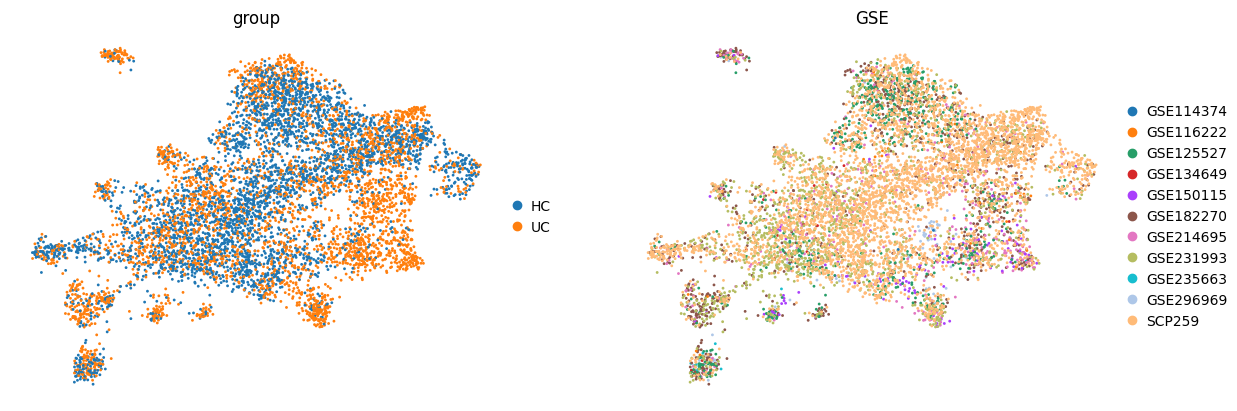

In [15]:
sc.pl.umap(sub, color=['group','GSE'], frameon=False)

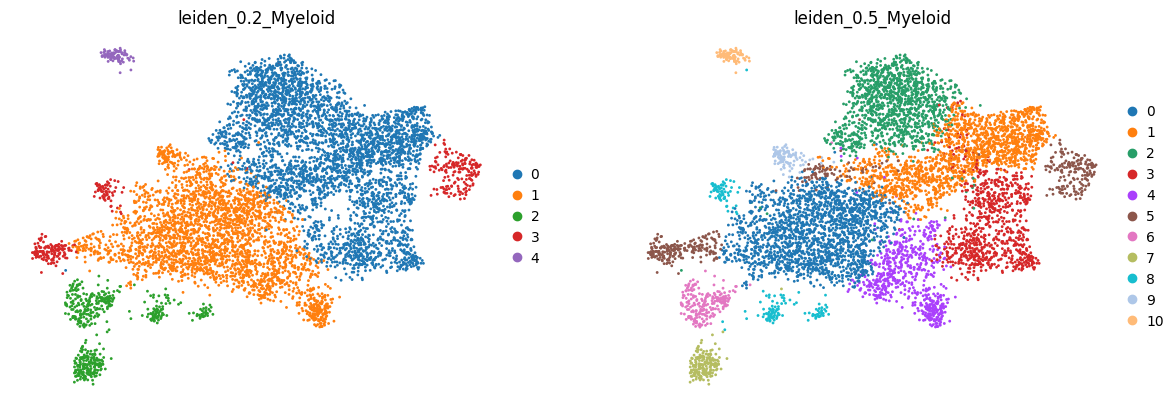

In [16]:
sc.pl.umap(sub, color=['leiden_0.2_Myeloid','leiden_0.5_Myeloid'], frameon=False)

## 查看marker表达

泛髓系检查marker

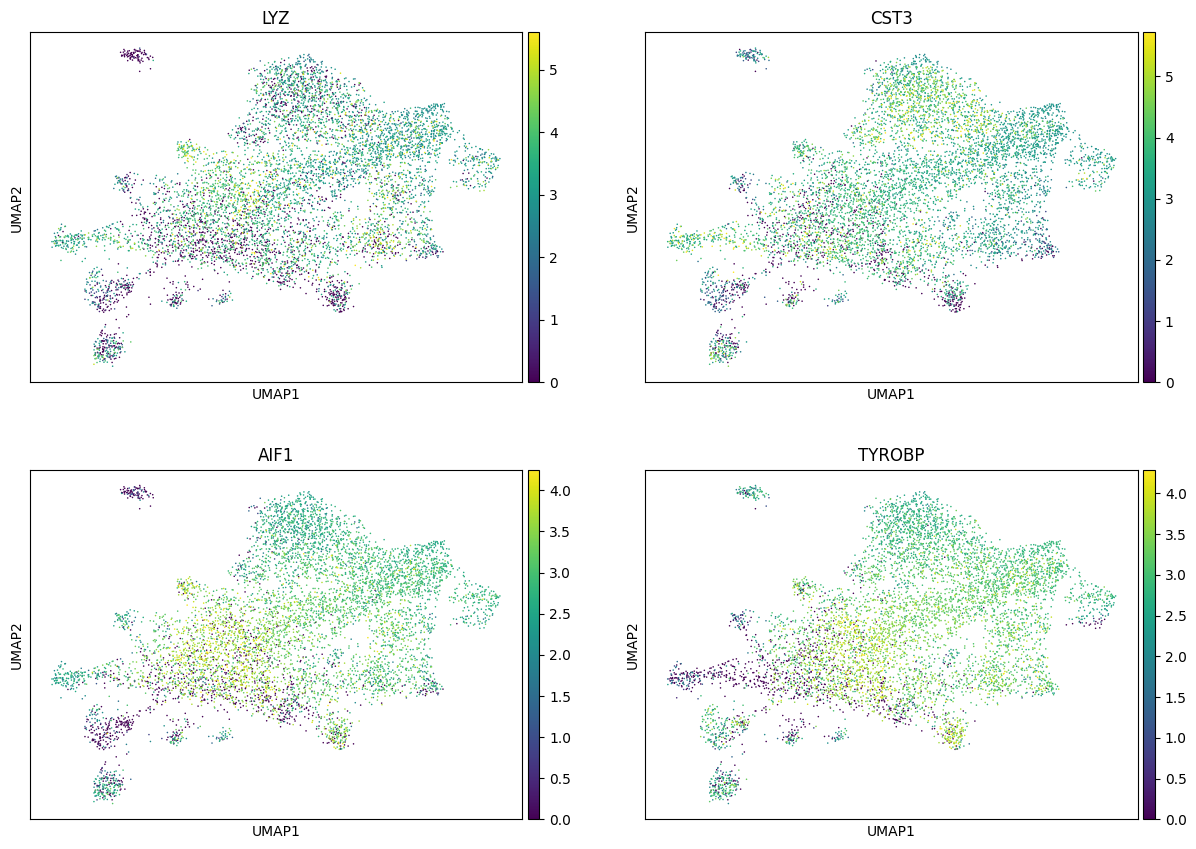

In [18]:
Lineage = ['LYZ', 'CST3', 'AIF1', 'TYROBP']
def safe_genes(genes, sub):
    return [g for g in genes if g in adata.var_names]

sc.pl.umap(sub, color=safe_genes(Lineage, sub), ncols=2, cmap="viridis", vmax="p99", vmin=0, size=5,)

In [24]:
l3_myeloid_markers = {
    # 1. 单核细胞 (Monocytes)
    # 特征：从血液新来的，还没有完全分化成巨噬细胞
    # 核心基因：VCAN (Versican) 和 FCN1 是区分单核与巨噬最“干净”的 Marker
    "Monocytes": ["VCAN", "FCN1", "CD14", "S100A8"], 

    # 2. 巨噬细胞 (Macrophages)
    # 特征：组织驻留或成熟的，体积大，吞噬功能强
    # 核心基因：补体基因 (C1QA) 和 清道夫受体 (CD163) 在成熟巨噬细胞中极高
    "Macrophages": ["C1QA", "C1QB", "CD163", "MRC1"], 

    # 3. 树突状细胞 (Dendritic Cells, DCs)
    # 特征：抗原呈递，高表达 MHC-II (HLA-DRA)，但不表达巨噬细胞的特征
    # 核心基因：CD1C (最常见的cDC2), CLEC9A (cDC1), LILRA4 (pDC), LAMP3 (成熟DC)
    "Dendritic_Cells": ["CD1C", "CLEC9A", "LILRA4", "LAMP3", "HLA-DRA"],

    # 4. 肥大细胞 (Mast Cells)
    # 特征：非常独特，通常独立成群
    # 核心基因：胰蛋白酶 (TPSAB1)
    "Mast_Cells": ["TPSAB1", "CPA3", "KIT"],
    
    # (备选) 中性粒细胞 (Neutrophils)
    # 如果你的数据质量很高或者处于急性炎症期，可能会有中性粒细胞
    "Neutrophils": ["CSF3R", "S100A9"] 
}
# 辅助函数：检查基因是否存在于数据集中，防止报错
def safe_genes(genes, sub):
    valid_genes = [g for g in genes if g in sub.var_names]
    if len(valid_genes) < len(genes):
        print(f"Warning: 忽略了缺失基因: {set(genes) - set(valid_genes)}")
    return valid_genes

正在绘制 Monocytes Markers...


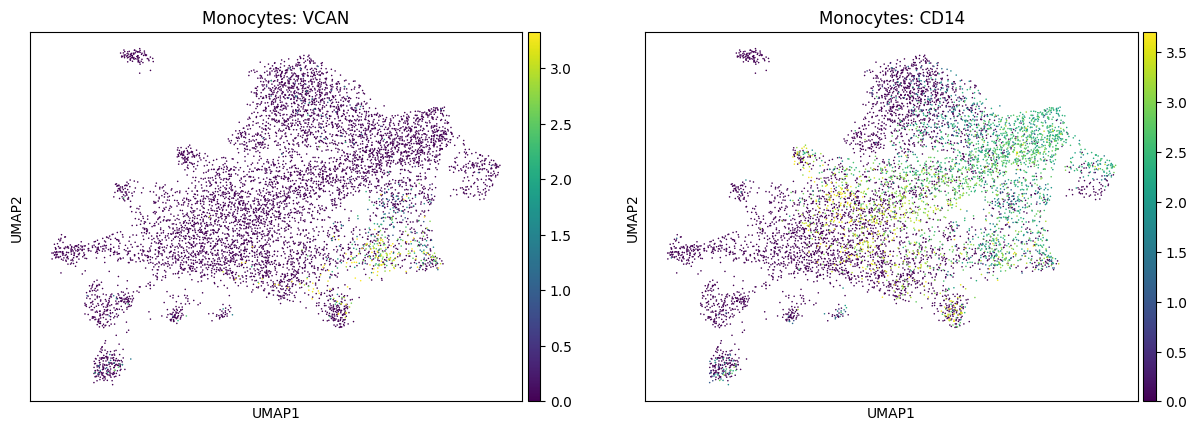

In [26]:
print("正在绘制 Monocytes Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_myeloid_markers["Monocytes"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Monocytes: {g}" for g in safe_genes(l3_myeloid_markers["Monocytes"], sub)])

正在绘制 Macrophages Markers...


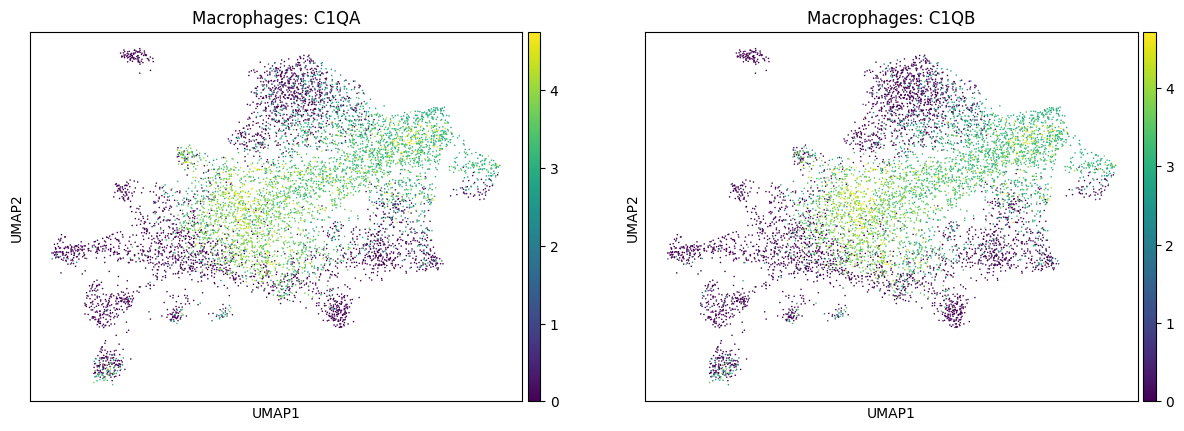

In [27]:
print("正在绘制 Macrophages Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_myeloid_markers["Macrophages"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Macrophages: {g}" for g in safe_genes(l3_myeloid_markers["Macrophages"], sub)])

正在绘制 Dendritic_Cells Markers...


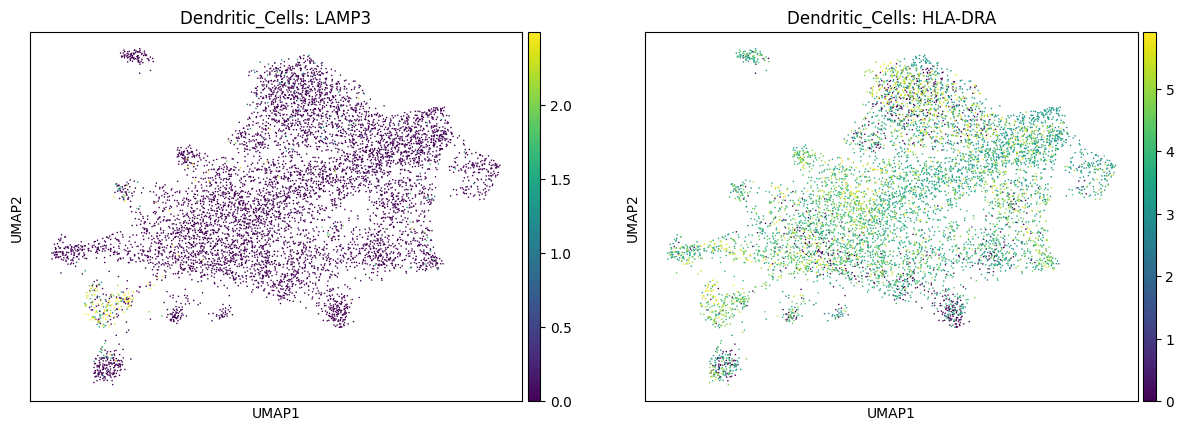

In [28]:
print("正在绘制 Dendritic_Cells Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_myeloid_markers["Dendritic_Cells"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Dendritic_Cells: {g}" for g in safe_genes(l3_myeloid_markers["Dendritic_Cells"], sub)])

正在绘制 Mast_Cells Markers...


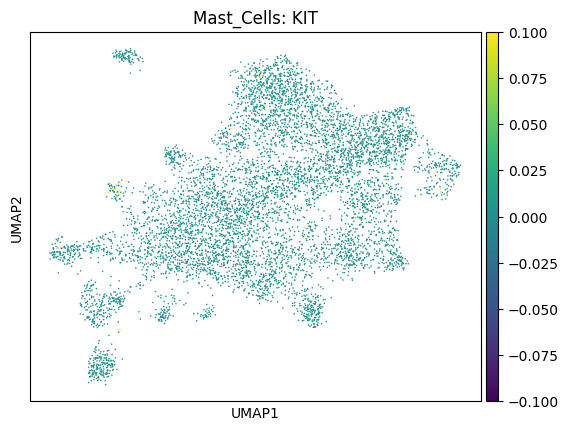

In [29]:
print("正在绘制 Mast_Cells Markers...")
sc.pl.umap(sub, 
           color=safe_genes(l3_myeloid_markers["Mast_Cells"], sub), 
           ncols=3, cmap="viridis", vmax="p99", vmin=0, size=5, 
           title=[f"Mast_Cells: {g}" for g in safe_genes(l3_myeloid_markers["Mast_Cells"], sub)])

## 差异分析

In [31]:
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid', 'group_colors', 'GSE_colors', 'leiden_0.2_Myeloid_colors', 'leiden_0.5_Myeloid_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

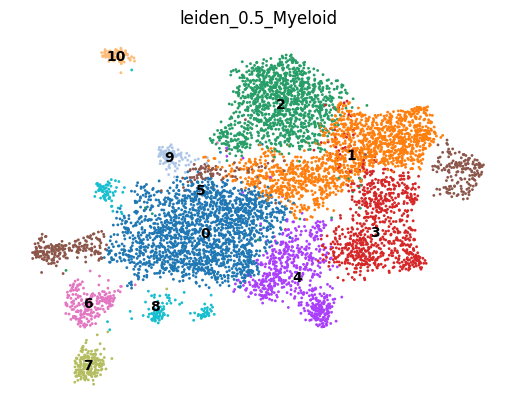

In [35]:
sc.pl.umap(sub, color=['leiden_0.5_Myeloid'], frameon=False, ncols=2, legend_loc='on data')

In [33]:
if 'leiden_0.5_Myeloid' in sub.obs.columns:
    sub.obs['leiden_0.5_Myeloid'] = sub.obs['leiden_0.5_Myeloid'].astype('category')

# 2. 运行差异分析
print("正在进行差异基因分析...")
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.5_Myeloid', 
    method='wilcoxon', 
    use_raw=True, 
    pts=True
)
print("分析完成！")

正在进行差异基因分析...
分析完成！


In [34]:
# 获取所有分组的名称
groups = sub.obs['leiden_0.5_Myeloid'].cat.categories

# 初始化一个字典来存储结果
top10_genes = {}

print("=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===")
for group in groups:
    # 提取该群的差异基因数据框
    df = sc.get.rank_genes_groups_df(sub, group=group)
    
    # 筛选条件：通常我们关注上调的基因 (logfoldchanges > 0)
    # 按 score 降序排列（score 综合了表达差异和显著性）
    top_genes = df[df['logfoldchanges'] > 0].sort_values('scores', ascending=False).head(10)['names'].tolist()
    
    top10_genes[group] = top_genes
    print(f"Cluster {group}: {', '.join(top_genes)}")

# 如果你想把这个 Top10 列表存成一个 DataFrame 方便查看：
df_top10 = pd.DataFrame(top10_genes)
print("\nTop 10 基因表格预览：")
#display(df_top10)

# 可选：保存到 CSV
# df_top10.to_csv("L3_TNK_Top10_Markers.csv")

=== 各亚群 Top 10 差异基因 (基于 Score 排序) ===
Cluster 0: RPL41, RPL12, FTL, RPL21, TMSB4X, RPL13A, HLA-DPB1, RPL35, RPS28, RPL26
Cluster 1: PLD3, LGMN, ACP5, CTSD, C1QB, SLC40A1, TMEM176B, STAB1, APOE, FCGRT
Cluster 2: GPR183, KLF4, CXCR4, ZFP36, NR4A2, JUNB, CORO1A, RGS2, DUSP2, TUBA1A
Cluster 3: SOD2, TIMP1, PLAUR, NFKBIA, CD44, NAMPT, IL1B, SRGN, NEAT1, BTG1
Cluster 4: SOD2, SAT1, SRGN, MALAT1, NFKBIA, NEAT1, H3F3B, FOSB, DUSP1, NAMPT
Cluster 5: H2AFZ, TUBB, SNX3, STMN1, MZT2A, HMGN2, HMGB2, HMGB1, CPVL, HMGN1
Cluster 6: TXN, MARCKSL1, FSCN1, TMSB10, CCR7, BIRC3, LAMP3, ACTB, IDO1, ID2
Cluster 7: CD3D, IL32, TRBC2, MALAT1, CD2, CD7, TRAC, CD3E, KLRB1, CD69
Cluster 8: LTB, CD79A, RPL3, RPS5, RPS19, RPL13, RPL5, RPS18, RPS8, RPS6
Cluster 9: MMP9, APOE, PTGDS, ATOX1, ENPP2, CTSD, FUCA1, ITM2B, HLA-A, PSAP
Cluster 10: GZMB, PLAC8, IRF7, SEC61B, C12orf75, MZB1, TCF4, MALAT1, LDLRAD4, GPR183

Top 10 基因表格预览：


### 针对第0群细胞进行差异分析

In [36]:
# 1. 运行差异分析 (Cluster 0 vs. Rest)
# ==============================================
print("正在对 Cluster 0 进行差异分析...")

# sc.tl.rank_genes_groups 用于计算差异基因
# groups=['0']: 指定只计算第 0 群
# reference='rest': 指定对比对象为“其余所有细胞”
sc.tl.rank_genes_groups(
    sub, 
    groupby='leiden_0.5_Myeloid', 
    groups=['0'],      
    reference='rest',  
    method='wilcoxon', # 推荐使用的统计检验方法
    use_raw=True,      # 使用标准化后的原始数据(log-transformed)
    pts=True           # 计算基因在组内/组外的表达比例(pct)
)

# ==============================================
# 2. 提取并整理 Top 10 Marker
# ==============================================
# 获取结果 DataFrame
c0_df = sc.get.rank_genes_groups_df(sub, group='0')

# 筛选标准：
# - logfoldchanges > 0.25 (过滤掉差异太小的)
# - pvals_adj < 0.05 (过滤掉不显著的)
# 按 score (综合得分) 降序排列，取前 10 个
top10_c0 = c0_df[
    (c0_df['logfoldchanges'] > 0.25) & 
    (c0_df['pvals_adj'] < 0.05)
].sort_values('scores', ascending=False).head(10)

# ==============================================
# 3. 打印结果
# ==============================================
print("\n=== Cluster 0 Top 10 特异性 Marker ===")
# 格式化展示：基因名 | Log2倍数变化 | 调整后P值 | 组内表达比例 | 组外表达比例
print(top10_c0[['names', 'logfoldchanges', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']].to_string(index=False))

正在对 Cluster 0 进行差异分析...

=== Cluster 0 Top 10 特异性 Marker ===
   names  logfoldchanges     pvals_adj  pct_nz_group  pct_nz_reference
   RPL41        0.756655 4.045756e-214      0.941530          0.965086
   RPL12        0.374395 6.581384e-166      0.892350          0.956266
     FTL        0.805009 2.017851e-142      0.979235          0.986770
   RPL21        0.558839 5.322645e-131      0.853005          0.917677
  TMSB4X        0.743803 3.044722e-118      0.993443          0.989342
  RPL13A        0.408976 1.723197e-113      0.915301          0.963800
HLA-DPB1        0.675473 1.234760e-108      0.877596          0.857589
   RPL26        0.260986  6.188312e-99      0.828415          0.938074
  RPL27A        0.261601  1.178177e-93      0.839891          0.938626
  TMSB10        0.427185  5.556500e-83      0.972131          0.984013


## 结果

In [37]:
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid', 'group_colors', 'GSE_colors', 'leiden_0.2_Myeloid_colors', 'leiden_0.5_Myeloid_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [39]:
l3_myeloid_map = {
    # --- 巨噬细胞亚群 ---
    '1': 'Mac Resident',      # 组织驻留 (C1Q+)
    '3': 'Mac Inflammatory',  # 促炎 (IL1B+)
    '4': 'Mac Activated',     # 激活/应激 (NFKBIA+)
    '9': 'Mac Remodeling',    # 组织重塑 (MMP9+)
    
    # --- 单核/DC 亚群 ---
    '2': 'Mono Classical',    # 经典单核 (KLF4+)
    '6': 'DC Mature',         # 成熟DC (LAMP3+)
    '10': 'pDC',              # 浆细胞样DC (IRF7+)
    
    # --- 状态/其他 ---
    '5': 'Prolif Myeloid',    # 增殖状态
    
    # --- 待剔除 (杂质/低质量) ---
    '0': 'Low Quality',       # 建议剔除
    '7': 'Contaminants',        # T细胞混杂，剔除
    '8': 'Contaminants'         # B细胞混杂，剔除
}

In [40]:
# 2. 应用注释到新列 'L3'
# ----------------------------------------------------------
# 确保聚类列是字符串类型，以便匹配字典的 Key
cluster_col = 'leiden_0.5_Myeloid' 

if cluster_col in sub.obs.columns:
    # 创建新列 L3
    sub.obs['L3'] = sub.obs[cluster_col].astype(str).map(l3_myeloid_map)
    
    # 将 L3 转为 category 类型，方便后续绘图和排序
    sub.obs['L3'] = sub.obs['L3'].astype('category')
    
    print("注释已添加至 sub.obs['L3'] 列。")
    
    # 打印注释后的统计信息
    print("\n注释统计 (细胞数):")
    print(sub.obs['L3'].value_counts())

else:
    print(f"错误: 未找到列名 '{cluster_col}'，请检查您的 adata.obs。")

注释已添加至 sub.obs['L3'] 列。

注释统计 (细胞数):
L3
Low Quality         1830
Mac Resident        1529
Mono Classical      1232
Mac Inflammatory     823
Mac Activated        628
Prolif Myeloid       469
Contaminants         362
DC Mature            215
Mac Remodeling        99
pDC                   85
Name: count, dtype: int64


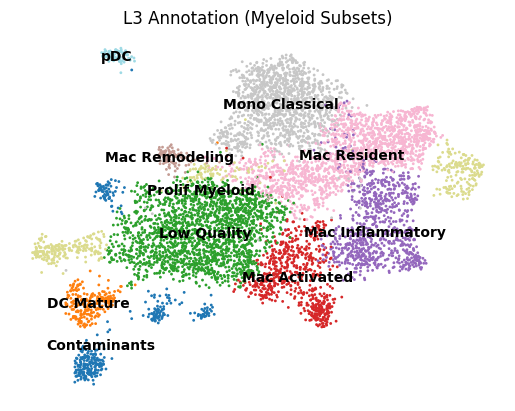

In [41]:
sc.pl.umap(
    sub, 
    color='L3', 
    title='L3 Annotation (Myeloid Subsets)', 
    frameon=False, 
    legend_loc='on data',  # 标签直接标在图上
    legend_fontsize=10,
    palette='tab20'        # 使用区分度较高的色板
)

In [42]:
import os
import matplotlib.pyplot as plt

# 绘制并保存 UMAP 图
fig_path = os.path.join(FIG_DIR, "L3_Myeloid_annotation_UMAP.png")

sc.pl.umap(
    sub,
    color=["L3"],
    frameon=False,
    title="L3 Myeloid annotation",  # 英文标题
    save=None,  # 我们手动保存，不用 Scanpy 自动保存
    show=False  # 防止 Notebook 中立即弹出
)

# 手动保存图片（可控格式和分辨率）
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"[Saved figure] → {fig_path}")


[Saved figure] → /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/figs/L3_Myeloid_annotation_UMAP.png


In [43]:
sub

AnnData object with n_obs × n_vars = 7272 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid', 'L3'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'REFERENCE_MANU', 'hvg', 'log1p', 'umap', 'neighbors', 'leiden_0.2_Myeloid', 'leiden_0.5_Myeloid', 'group_colors', 'GSE_colors', 'leiden_0.2_Myeloid_colors', 'leiden_0.5_Myeloid_colors', 'rank_genes_groups', 'L3_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [44]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage"             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
    'L3'
]
out_cols = [c for c in wanted_cols if c in sub.obs.columns]

sub.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/L3_Myeloid_summary.csv


In [45]:
sub.write_h5ad(OUT_H5AD, compression="gzip")